# Зареждане на необходимите библиотеки

In [8]:
import pandas as pd
import geopandas as gpd # Необходима библиотека за географските данни, с които разполагаме
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.diagnostic import het_breuschpagan

# Четене и обработване на данните

In [9]:
data = pd.read_excel("Real estate valuation.xlsx", index_col = 'No')
data

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,,,,,,,
1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...
410,2013.000000,13.7,4082.01500,0,24.94155,121.50381,15.4
411,2012.666667,5.6,90.45606,9,24.97433,121.54310,50.0
412,2013.250000,18.8,390.96960,7,24.97923,121.53986,40.6


### Кратко описание на характеристиките 

| Variable Name | Role    | Type       | Description                                                          | Units                                          |
| ------------- | ------- | ---------- | -------------------------------------------------------------------- | ---------------------------------------------- |
| No            | ID      | Integer    | —                                                                    | —                                              |
| X1            | Feature | Continuous | transaction date (e.g., 2013.250 = 2013 March; 2013.500 = 2013 June) | —                                              |
| X2            | Feature | Continuous | house age                                                            | year                                           |
| X3            | Feature | Continuous | distance to the nearest MRT station                                  | meter                                          | no             |
| X4            | Feature | Integer    | number of convenience stores in the living circle on foot            | integer                                        |
| X5            | Feature | Continuous | latitude (geographic coordinate)                                     | degree                                         |
| X6            | Feature | Continuous | longitude (geographic coordinate)                                    | degree                                         |
| Y             | Target  | Continuous | house price of unit area                                             | 10000 New Taiwan Dollar/Ping (1 Ping = 3.3 m²) |


Бърз преглед на данните в колоните. Нека проверим и за липсващи стойносит.

In [10]:
print(data.isnull().sum()) 

X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64


Няма липсващи стойности. Нека видим от какъв тип са данните ни.

In [11]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 414 entries, 1 to 414
Data columns (total 7 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X1 transaction date                     414 non-null    float64
 1   X2 house age                            414 non-null    float64
 2   X3 distance to the nearest MRT station  414 non-null    float64
 3   X4 number of convenience stores         414 non-null    int64  
 4   X5 latitude                             414 non-null    float64
 5   X6 longitude                            414 non-null    float64
 6   Y house price of unit area              414 non-null    float64
dtypes: float64(6), int64(1)
memory usage: 25.9 KB
None


In [12]:
data.describe()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148953,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281995,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.666667,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.916667,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.166667,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.416667,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583333,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


Всички колони са от числов тип. Ще преобразуваме времевите данни като `X1 transaction date` да измерват изминатия брой дни отчетени от закупуването на първия имот. Географските данни ще ги преобразуваме по два начина. 
- Единият ще е да ги преобразуваме от WGS84 (градуси) към проектирана координатна система в метри, за да получим линейни координати $x$,$y$ в метри. 
- Другият ще бъде като конструираме нов фийчър на база геометрията на точките – например разстояние в метри от всяко жилище до центъра (центроида) на наблюдаваните имоти.

In [13]:
def to_datetime(col):
    x = pd.to_numeric(col, errors="coerce")
    year = np.floor(x).astype("Int64")
    frac = x - year.astype(float)
    month = np.round(frac * 12).astype("Int64").clip(lower=1, upper=12)
    return pd.to_datetime({"year": year, "month": month, "day": 1}, errors="coerce")

data["transaction_dt"] = to_datetime(data["X1 transaction date"])

data["transaction_dt"] = to_datetime(data["X1 transaction date"])
data["trans_days"] = (data["transaction_dt"] - data["transaction_dt"].min()).dt.days

In [14]:
# Географска обработка
lat = pd.to_numeric(data["X5 latitude"], errors="coerce")
lon = pd.to_numeric(data["X6 longitude"], errors="coerce")

geodata = gpd.GeoDataFrame(
    data.copy(),
    geometry=gpd.points_from_xy(lon, lat),
    crs="EPSG:4326"
)

# Преобразуване в метри
geodata_m = geodata.to_crs("EPSG:32651")

data["x_m"] = geodata_m.geometry.x
data["y_m"] = geodata_m.geometry.y

# Центриране
data["x_m_c"] = data["x_m"] - data["x_m"].mean()
data["y_m_c"] = data["y_m"] - data["y_m"].mean()

# Разстояние до центроида
centroid = geodata_m.unary_union.centroid
data["dist_to_centroid_m"] = geodata_m.geometry.distance(centroid)


# Ще трансформираме променливата X3 distance to the nearest MRT station чрез логаритъм с цел
# овладяване на големите опашки при разпределението на променливата.
# Можем спокойно да логаритмуваме колоната, тъй като нямаме отрицателни или нулеви стойности.

if data["X3 distance to the nearest MRT station"].min() > 0:
    data["log_mrt_dist"] = np.log(pd.to_numeric(data["X3 distance to the nearest MRT station"], errors="coerce"))


/var/folders/g9/_wg4wg092w75_x1y9dg99r_w0000gn/T/ipykernel_48133/1814298462.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = geodata_m.unary_union.centroid


In [15]:
def plot_hist_grid(df, cols, bins=30, max_cols=3, title="Histograms"):
    cols = list(cols)
    n = len(cols)

    ncols = min(max_cols, n)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.5*nrows))
    axes = np.array(axes).reshape(-1)

    for i, c in enumerate(cols):
        ax = axes[i]
        sns.histplot(x=c, bins=bins, ax=ax, data=df)
        ax.set_title(c)
        ax.set_xlabel(c)
        ax.set_ylabel("Count")
    for j in range(i+1, len(axes)):
        axes[j].axis("off")
    fig.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

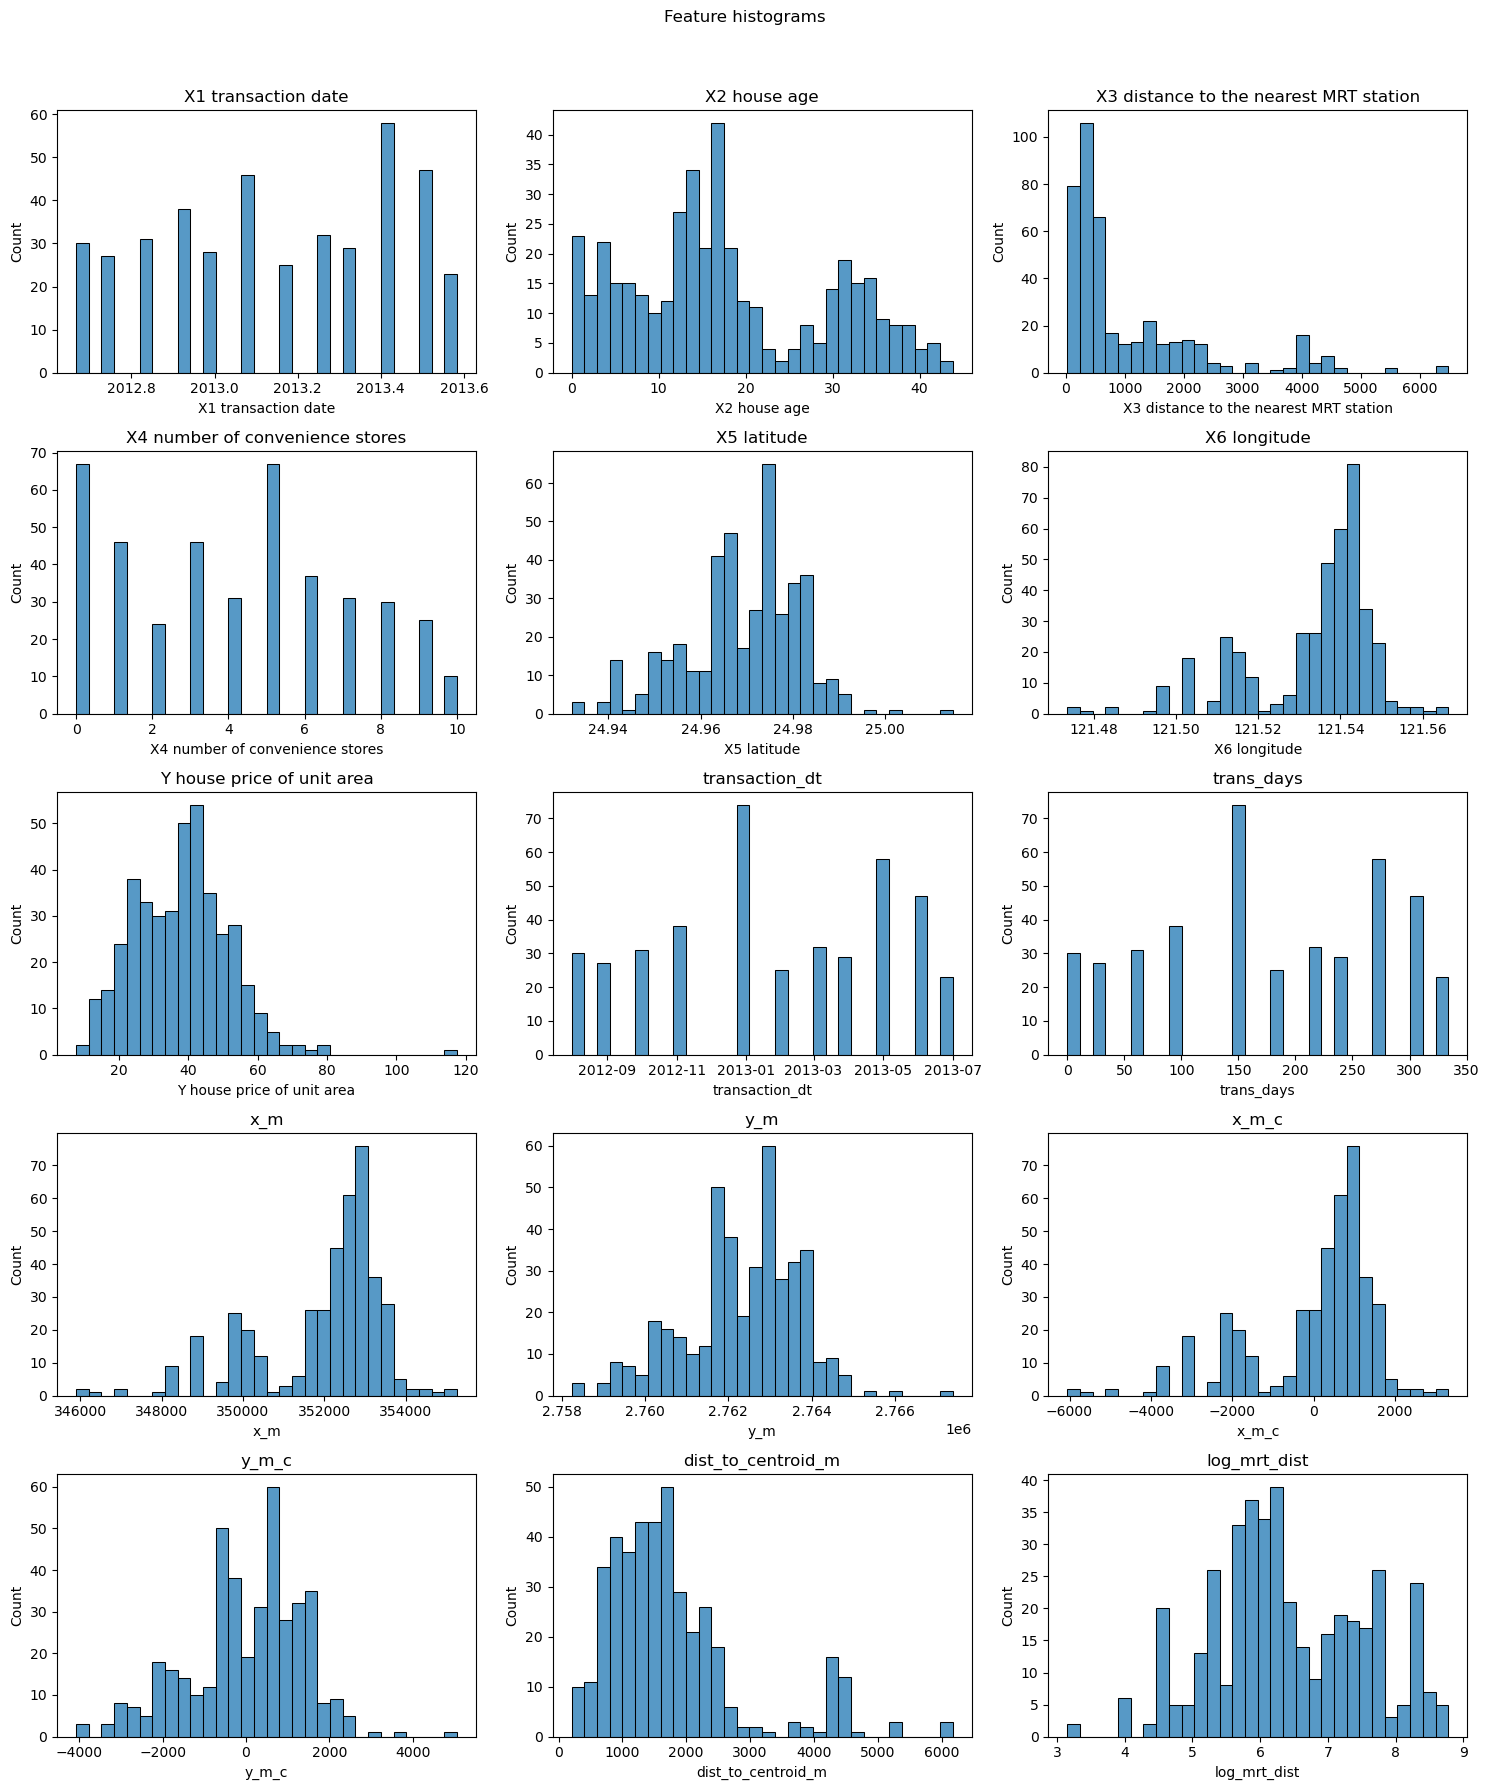

In [16]:
data_cols = data.columns

plot_hist_grid(data, data_cols, bins=30, title="Feature histograms")

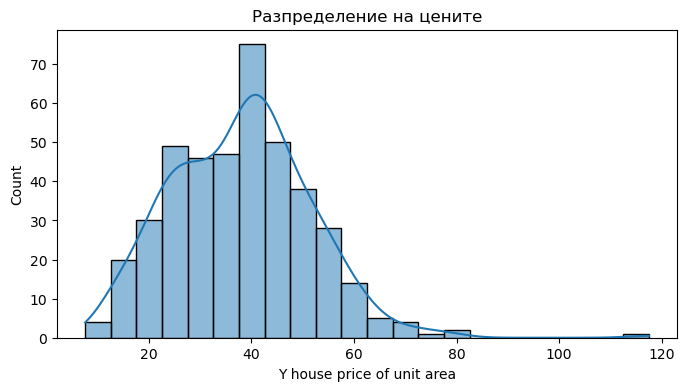

In [17]:
# Тarget разпределението
plt.figure(figsize=(8,4))
sns.histplot(data['Y house price of unit area'], kde=True)
plt.title("Разпределение на цените")
plt.show()

Нека разгледаме корелационната матрица.

In [18]:
cols_corr = [
    "trans_days",  
    "X2 house age",
    "X3 distance to the nearest MRT station",
    "X4 number of convenience stores",
    "x_m_c", "y_m_c",
    "dist_to_centroid_m",
    "log_mrt_dist",
    "Y house price of unit area"
]

corr_df = data[cols_corr].apply(pd.to_numeric, errors="coerce")
corr = corr_df.corr(method="pearson")

corr

,trans_days,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,x_m_c,y_m_c,dist_to_centroid_m,log_mrt_dist,Y house price of unit area
trans_days,1.000000,0.018335,0.071202,0.000207,-0.041067,0.021237,0.083408,0.105999,0.077617
X2 house age,0.018335,1.000000,0.025622,0.049593,-0.047814,0.055291,-0.027412,0.067322,-0.210567
X3 distance to the nearest MRT station,0.071202,0.025622,1.000000,-0.602519,-0.808764,-0.584081,0.916821,0.864920,-0.673613
X4 number of convenience stores,0.000207,0.049593,-0.602519,1.000000,0.451537,0.440841,-0.468999,-0.685516,0.571005
x_m_c,-0.041067,-0.047814,-0.808764,0.451537,1.000000,0.410656,-0.620282,-0.651272,0.526412
y_m_c,0.021237,0.055291,-0.584081,0.440841,0.410656,1.000000,-0.516399,-0.450946,0.542601
dist_to_centroid_m,0.083408,-0.027412,0.916821,-0.468999,-0.620282,-0.516399,1.000000,0.759358,-0.575781
log_mrt_dist,0.105999,0.067322,0.864920,-0.685516,-0.651272,-0.450946,0.759358,1.000000,-0.734339
Y house price of unit area,0.077617,-0.210567,-0.673613,0.571005,0.526412,0.542601,-0.575781,-0.734339,1.000000


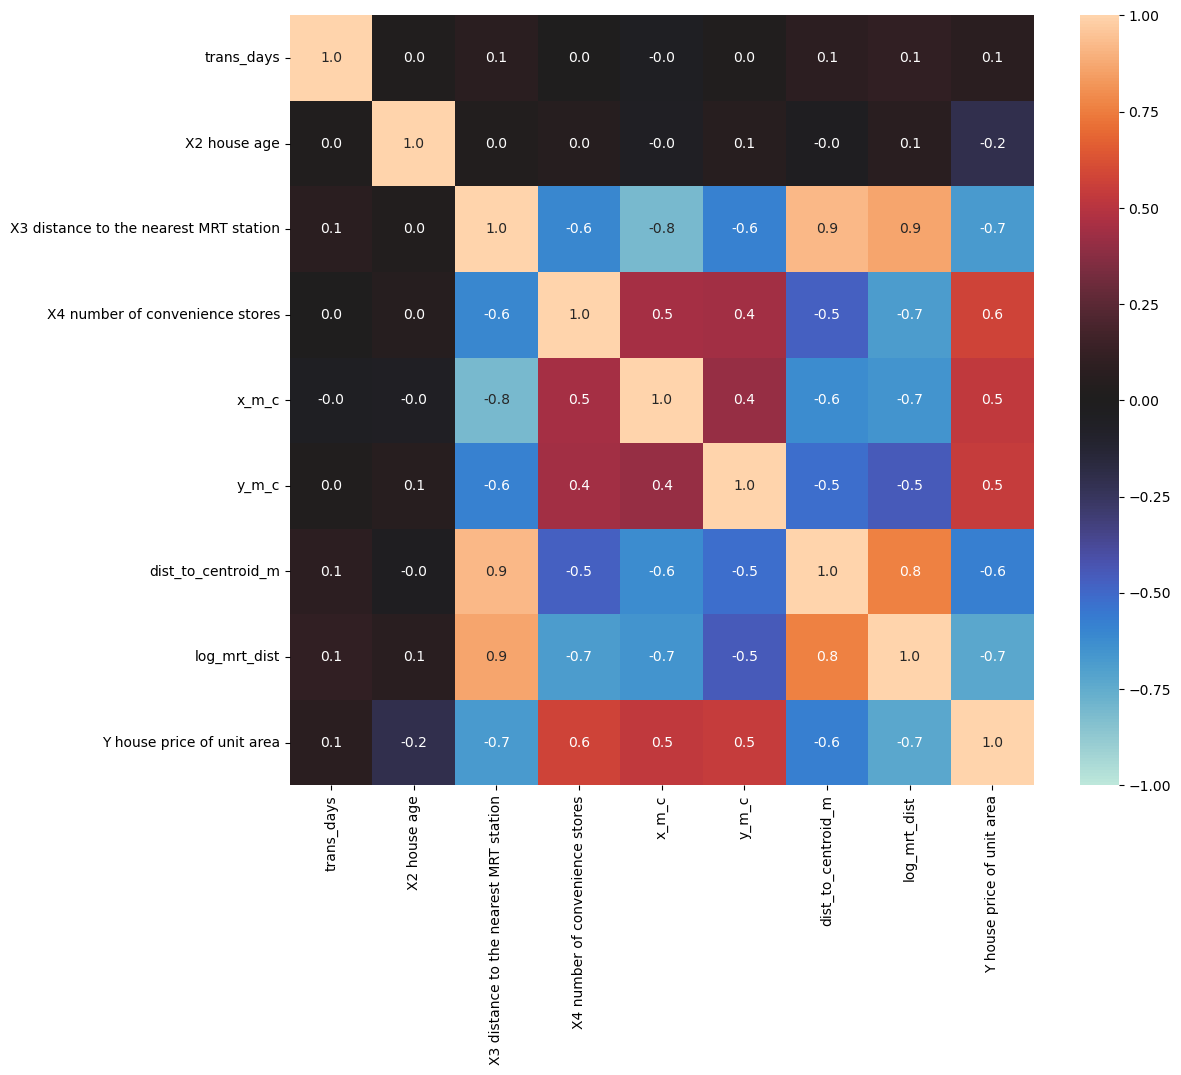

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(corr_df.corr(), 
            annot = True, 
            fmt='.1f', 
            vmin=-1, 
            vmax=1, 
            center=0)
plt.show()

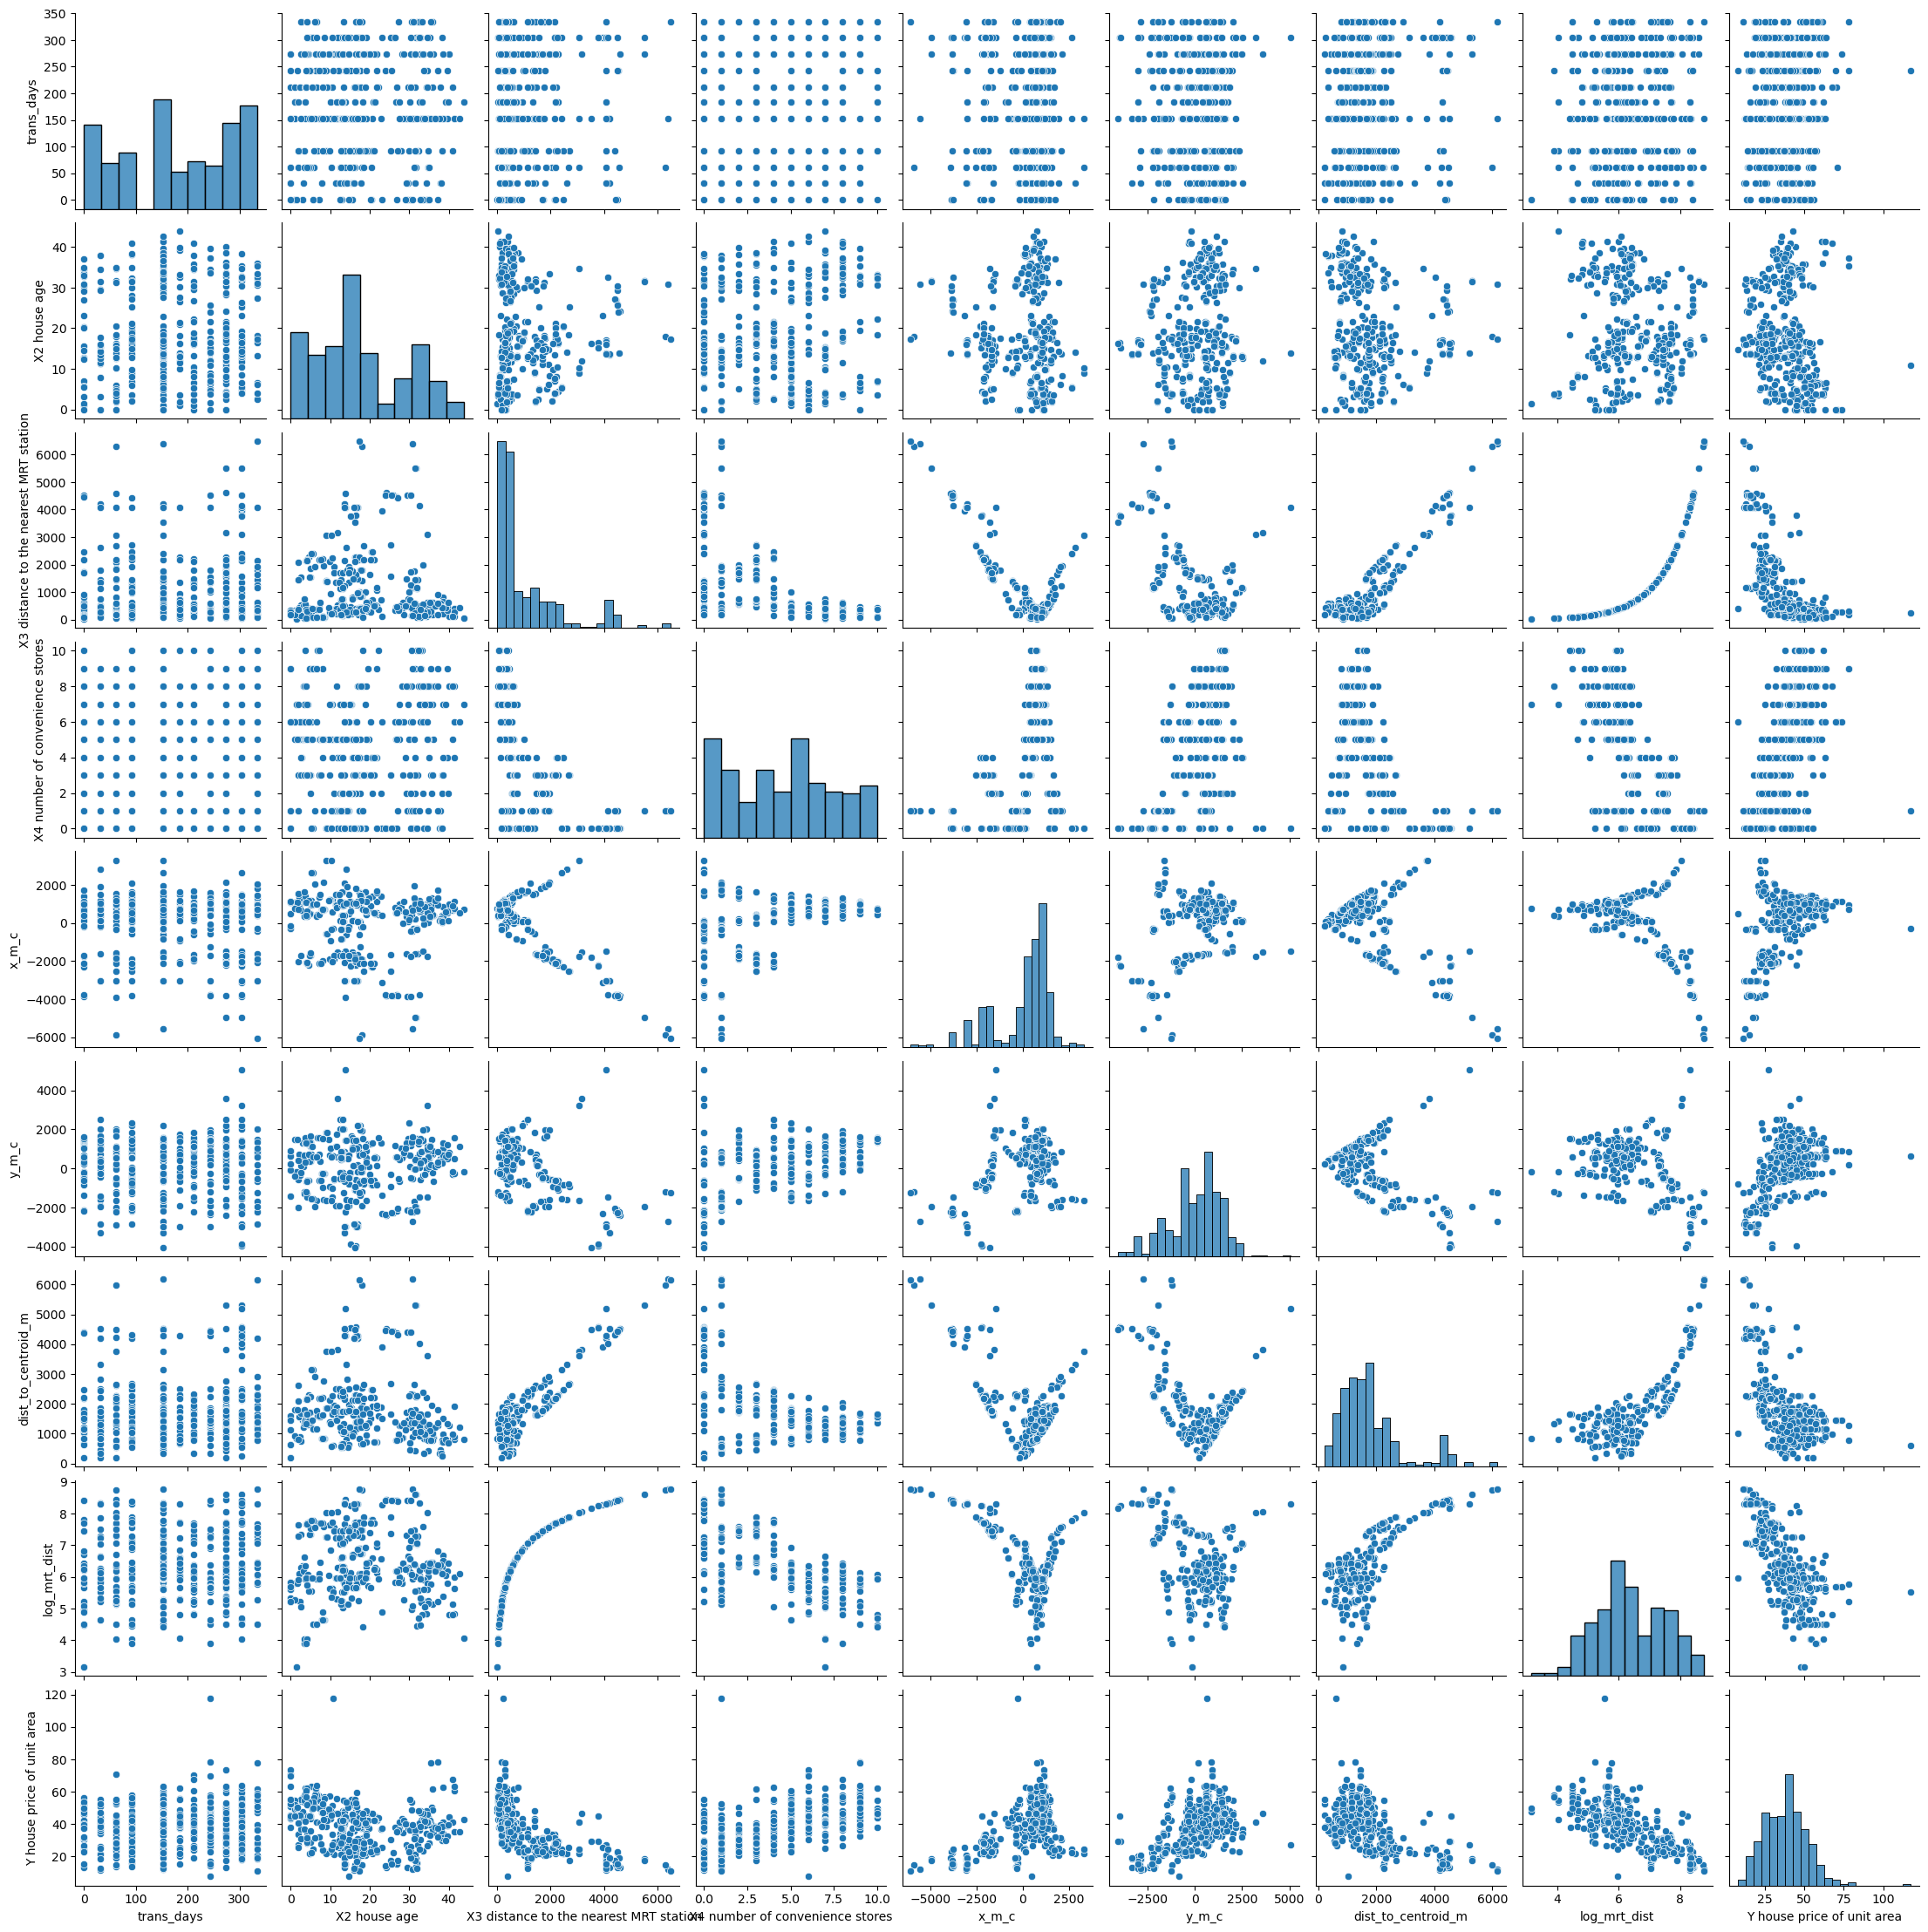

In [19]:
sns.pairplot(data[cols_corr])

Няколко извода от нашата корелационна матрица.

Корелация с таргета `Y house price of unit area`:
- `trans_days` - много слаба корелация. Не се наблюдава значително покачване на цената след изминал период от време.
- `X2 house age` - отрицателна корелация. Това означава, че старите къщи имат по-ниска цена. Съвсем нормално и очаквано старите строежи да са по-евтини от новопостроените.
- `X3 distance to the nearest MRT station` - силна отрицателна корелация. Това означава, че колкото по-далеч сме от транзитна станция толкова по-ниска е цената.
- `X4 number of convenience stores` - силна корелация, тоест колкото повече магазини има наоколо толкова по-скъп е имотът.
- `x_m_c` и `y_m_c` - силна корелация, което означава, че локацията има значение спрямо цената.
- `log_mrt_dist` - силна отрицателна корелация. Това означава, че след логаритмичната трансформация на нашите данни получаваме по-висока линейна зависимост, което може да подобри линейния модел.

Корелация измежду предикторите:
- Най-висока е корелацията между `X3 MRT distance` & `dist_to_centroid_m`. Това ще рече, че двата предиктора биха носили еднаква информация в нашия краен модел.
- `X3 MRT distance` също има висока отрицателна корелация с `x_m_c` и `y_m_c`. Тоест както очакваме, разстоянието до транзитна станция има корелация с локацията. 
- Тъй като `log_mrt_dist` е логаритмична трансформация на `X3 MRT distance`, то заключенията важат и за тази колона като отново имаме силна корелация между `dist_to_centroid_m` и отрицателна корелация между `x_m_c` и `y_m_c`

Корелационната матрица ни подсказва кои променливи да включим в нашия модел. Първо ще започнем с базов модел M0, в който ще включим първоначалните характеристики преди обработка. След това ще тренираме модел с обработените характеристики като ще заменим `X3 MRT distance` с `log_mrt_dist` тъй като тя е по-свързана с таргета и носи повече информация. След това, поради високата корелация между `log_mrt_dist` и `dist_to_centroid_m` ще разгледаме два отделни модела, всеки използвайки един от двата фийчъра. 


# Трениране на линеен OLS модел

Ще започнем търсенето на нашия модел като първо разгледаме линейния модел. Ще оценим и сравним тренираните ни линейни модели по следните характеристики:
- RMSE / MAE
- R^2 score
- AIC / BIC информационни критерии

След като сме намерили най-оптималният ни модел след това трябва да проверим дали условията за нормалност са изпълнени, а именно ще направим:
- Shapiro-Wilk тест за проверка нормалност на остатъците
- Проверка за хомоскедастичност чрез тест на Brausch-Pagan

In [20]:
ycol = "Y house price of unit area"

# Дефиниране на моделите
models = {
    "M0_baseline": ["trans_days", "X2 house age", "X3 distance to the nearest MRT station",
                    "X4 number of convenience stores"],

    "M1_logdist": ["trans_days", "X2 house age", "log_mrt_dist",
                   "X4 number of convenience stores"],

    "M2_xy": ["trans_days", "X2 house age",
              "X4 number of convenience stores", "x_m_c", "y_m_c"],

    "M3_centroid": ["trans_days", "X2 house age", "X4 number of convenience stores", "dist_to_centroid_m"]
}

all_X_cols = sorted({c for cols in models.values() for c in cols})
needed_cols = [ycol] + all_X_cols

df = data[needed_cols].copy()

In [21]:
def fit_ols(X, y):
    X_c = sm.add_constant(X)
    model = sm.OLS(y, X_c).fit()
    return model

rows = []

for name, cols in models.items():
    df_i = df[[ycol] + cols].copy()

    X = df_i[cols].astype(float)
    y = df_i[ycol].astype(float)

    model = fit_ols(X, y)

    resid = model.resid
    mse_in = np.mean(resid**2)
    rmse_in = np.sqrt(mse_in)

    rows.append({
        "model": name,
        "n_used": int(model.nobs),
        "R2": model.rsquared,
        "Adj_R2": model.rsquared_adj,
        "AIC": model.aic,
        "BIC": model.bic,
        "RMSE_in": rmse_in
    })

    print("\n" + "="*86)
    print(f"Model: {name}  (n={int(model.nobs)})")
    print("="*86)
    print(model.summary())

results = pd.DataFrame(rows).sort_values(["BIC", "AIC"])
print("\n" + "="*86)
print("Model Comparison")
print("="*86)
print(results)



Model: M0_baseline  (n=414)
                                OLS Regression Results                                
Dep. Variable:     Y house price of unit area   R-squared:                       0.555
Model:                                    OLS   Adj. R-squared:                  0.551
Method:                         Least Squares   F-statistic:                     127.5
Date:                        Tue, 10 Feb 2026   Prob (F-statistic):           1.50e-70
Time:                                11:23:48   Log-Likelihood:                -1500.2
No. Observations:                         414   AIC:                             3010.
Df Residuals:                             409   BIC:                             3030.
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                                             coef    std err          t      P>|t|      [0.025      0

# Изводи от моделите

- M1_logdist има най-ниска стойност на RMSE, което означава, че грешките са по-малки отколкото в другите модели. Затова ще продължим с неговото разглеждане.
- При всички модели забелячваме, че Durbin-Watson score-ът е над 2, което означава, че имаме отрицателна автокорелация. 

=== OLS Model: M1_logdist ===
                                OLS Regression Results                                
Dep. Variable:     Y house price of unit area   R-squared:                       0.600
Model:                                    OLS   Adj. R-squared:                  0.596
Method:                         Least Squares   F-statistic:                     153.6
Date:                        Tue, 10 Feb 2026   Prob (F-statistic):           4.40e-80
Time:                                11:23:48   Log-Likelihood:                -1477.9
No. Observations:                         414   AIC:                             2966.
Df Residuals:                             409   BIC:                             2986.
Df Model:                                   4                                         
Covariance Type:                    nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]


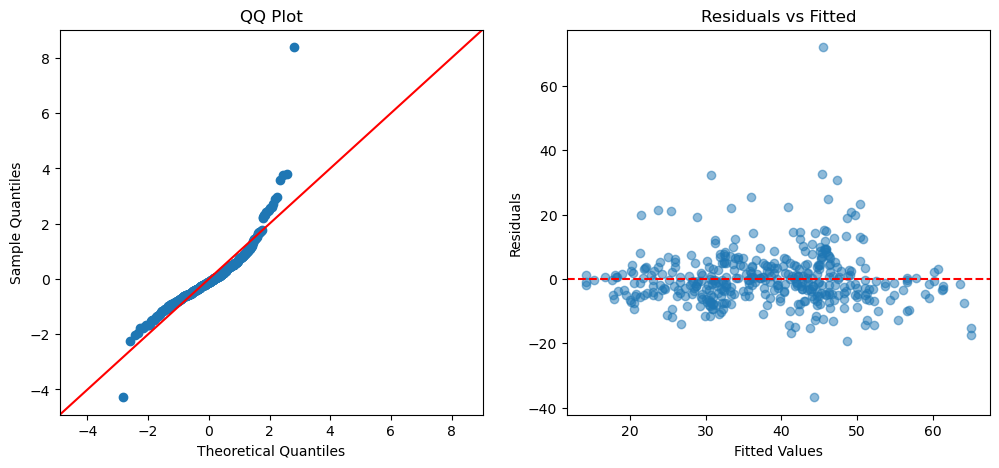

In [22]:
cols = models["M1_logdist"]
df_clean = data[[ycol] + cols].copy()

X = sm.add_constant(df_clean[cols])
y = df_clean[ycol]

ols_model = sm.OLS(y, X).fit()

print(f"=== OLS Model: M1_logdist ===")
print(ols_model.summary())

residuals = ols_model.resid

# Shapiro-Wilk Тест за нормалност на остатъците
sh_stat, sh_p = stats.shapiro(residuals)
print(f"\nShapiro–Wilk test: W={sh_stat:.4f}, p={sh_p:.4g}")
if sh_p < 0.05:
    print("-> Остатъците не са нормално разпределени: (p < 0.05). Отхвърляме Н_0!")

# Breusch–Pagan Тест за хетероскедастичност
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(residuals, X)
print(f"\nBreusch–Pagan test: LM stat = {bp_lm:.4f},  p-value = {bp_lm_p:.4g}, F stat  = {bp_f:.4f},  p-value = {bp_f_p:.4g}")
if bp_f_p < 0.05:
    print("-> Има хетероскедастичност (p < 0.05). Отхвърляме Н_0!")

# Графично представяне на остатъците
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# QQ Plot
sm.qqplot(residuals, line='45', fit=True, ax=ax[0])
ax[0].set_title("QQ Plot")

# Residuals vs Fitted (Проверка за Хетероскедастичност)
ax[1].scatter(ols_model.fittedvalues, residuals, alpha=0.5)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel("Fitted Values")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Residuals vs Fitted")
plt.show()

Установяваме, че остатъците не са нормално разпределени както и че моделът е хетероскедастичен, тоест дисперсията на грешките зависи от предикторите, следователно моделът ни не е коректен тъй като не изпълнява предположенията за обикновена линейна регресия чрез най-малки квадрати и трябва да минем към модели, които не предполагат нормално разпределение. Затова ще пробваме GLM модели като тестваме Гама разпределение.

In [23]:
def fit_glm(X, y):
    X_c = sm.add_constant(X)
    model = sm.GLM(y, X_c, family=sm.families.Gamma(link=sm.families.links.Log())).fit()
    return model

rows = []

n = df.shape[0]

for name, cols in models.items():
    X = df[cols].astype(float)
    y = df[ycol].astype(float)

    res = fit_glm(X, y)

    yhat = res.fittedvalues
    rmse_in = float(np.sqrt(np.mean((y - yhat) ** 2)))

    pseudo_r2 = float(1 - res.deviance / res.null_deviance)

    k = int(res.df_model) + 1
    bic = float(-2 * res.llf + k * np.log(n))

    rows.append({
        "model": name,
        "n_used": int(res.nobs),
        "AIC": float(res.aic),
        "BIC": bic,
        "Pseudo_R2_Faraway": pseudo_r2,
        "RMSE_in": rmse_in
    })

    print("\n" + "="*86)
    print(f"Model: {name} (n={int(res.nobs)})  --  GLM Gamma(log-link)")
    print("="*86)
    print(res.summary())

results = pd.DataFrame(rows).sort_values(["BIC", "AIC"]).reset_index(drop=True)

print("\n" + "="*86)
print("Model Comparison")
print("="*86)
print(results)



Model: M0_baseline (n=414)  --  GLM Gamma(log-link)
                     Generalized Linear Model Regression Results                      
Dep. Variable:     Y house price of unit area   No. Observations:                  414
Model:                                    GLM   Df Residuals:                      409
Model Family:                           Gamma   Df Model:                            4
Link Function:                            Log   Scale:                        0.057796
Method:                                  IRLS   Log-Likelihood:                -1459.3
Date:                        Tue, 10 Feb 2026   Deviance:                       22.003
Time:                                11:23:48   Pearson chi2:                     23.6
No. Iterations:                            12   Pseudo R-squ. (CS):             0.7803
Covariance Type:                    nonrobust                                         
                                             coef    std err          z      

Като използваме GLM модел с Гама функция излиза, че базиовият модел m0_baseline има най-добри метрики спрямо останалите модели. Нисък RMSE скор и ниски AIC & BIC. Време е да преминем към анализи на остатъците.

                     Generalized Linear Model Regression Results                      
Dep. Variable:     Y house price of unit area   No. Observations:                  414
Model:                                    GLM   Df Residuals:                      409
Model Family:                           Gamma   Df Model:                            4
Link Function:                            log   Scale:                        0.057796
Method:                                  IRLS   Log-Likelihood:                -1459.3
Date:                        Tue, 10 Feb 2026   Deviance:                       22.003
Time:                                11:23:48   Pearson chi2:                     23.6
No. Iterations:                            12   Pseudo R-squ. (CS):             0.7803
Covariance Type:                    nonrobust                                         
                                             coef    std err          z      P>|z|      [0.025      0.975]
-----------------------

/opt/anaconda3/lib/python3.13/site-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


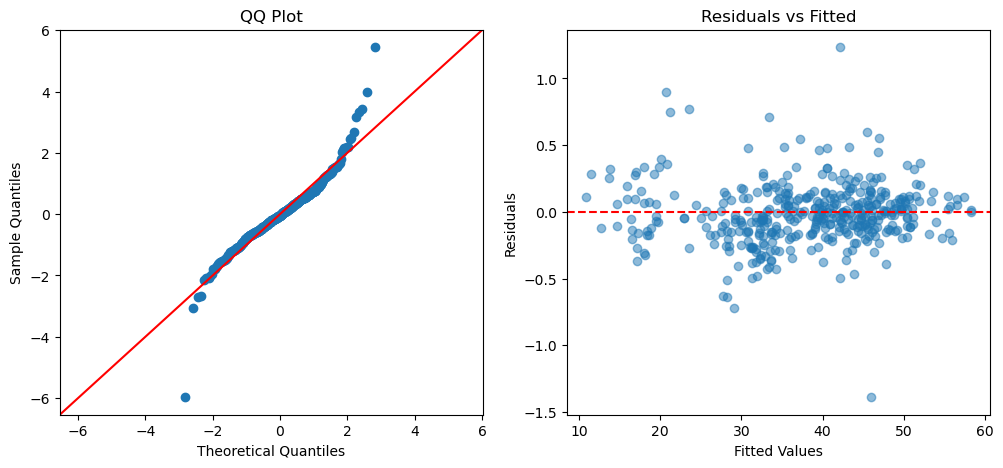

In [24]:
cols = models["M0_baseline"]
df_clean = data[[ycol] + cols].copy()

X = sm.add_constant(df_clean[cols])
y = df_clean[ycol]

model = sm.GLM(y, X, family=sm.families.Gamma(link=sm.families.links.log()))
results = model.fit()
print(results.summary())

# Оценка на Goodness-of-fit (Faraway formula)
# 1 - (Residual Deviance / Null Deviance)
pseudo_r2 = 1 - (results.deviance / results.null_deviance)
print(f"Faraway Pseudo R-squared: {pseudo_r2:.4f}")

# Анализ на остатъците (Residuals)
residuals = results.resid_deviance

# Графично представяне на остатъците
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# QQ Plot
sm.qqplot(residuals, line='45', fit=True, ax=ax[0])
ax[0].set_title("QQ Plot")

# Residuals vs Fitted (Проверка за Хетероскедастичност)
ax[1].scatter(results.fittedvalues, residuals, alpha=0.5)
ax[1].axhline(0, color='r', linestyle='--')
ax[1].set_xlabel("Fitted Values")
ax[1].set_ylabel("Residuals")
ax[1].set_title("Residuals vs Fitted")
plt.show()
